# Task 1.1 — ResNet-152 Baseline Setup & Fine-Tuning

In this notebook, we load an ImageNet pre-trained ResNet-152 backbone, replace its classification head for CIFAR-10, freeze the backbone, and fine-tune the classification head. We then record and plot training and validation performance.

c:\Users\moize\anaconda3\envs\geo\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
Files already downloaded and verified
Files already downloaded and verified


C:\Users\moize\OneDrive - Higher Education Commission\Desktop\Academics\ATML\PA0\atml-assignment0\task1_resnet152\src\train.py:84: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_cuda)
Epoch 1/5 [Train]:   0%|          | 0/782 [00:00<?, ?it/s]C:\Users\moize\OneDrive - Higher Education Commission\Desktop\Academics\ATML\PA0\atml-assignment0\task1_resnet152\src\train.py:28: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_cuda):
C:\Users\moize\OneDrive - Higher Education Commission\Desktop\Academics\ATML\PA0\atml-assignment0\task1_resnet152\src\train.py:64: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_cuda):


Epoch 1/5 | Train Loss: 0.7134 Acc: 0.7803 | Val Loss: 0.5293 Acc: 0.8224 | Time: 229.36s


Epoch 2/5 | Train Loss: 0.5124 Acc: 0.8293 | Val Loss: 0.4999 Acc: 0.8369 | Time: 205.03s


Epoch 3/5 | Train Loss: 0.4739 Acc: 0.8400 | Val Loss: 0.4663 Acc: 0.8472 | Time: 204.95s


Epoch 4/5 | Train Loss: 0.4519 Acc: 0.8473 | Val Loss: 0.4604 Acc: 0.8455 | Time: 204.99s


Epoch 5/5 | Train Loss: 0.4355 Acc: 0.8508 | Val Loss: 0.4589 Acc: 0.8508 | Time: 205.27s


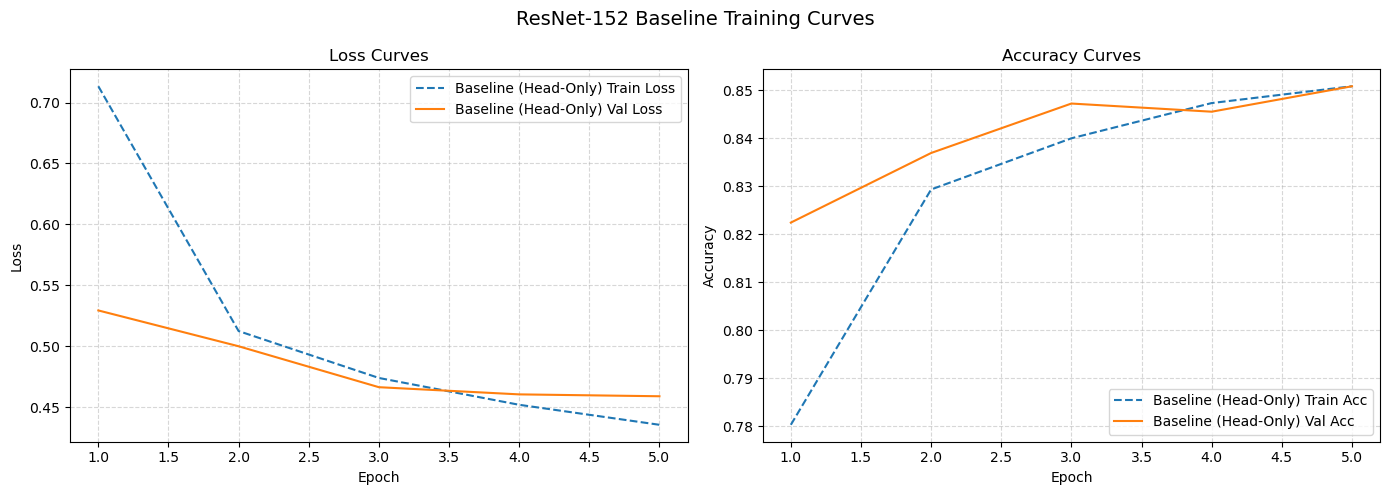

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from task1_resnet152.src.data import get_cifar10_loaders
from task1_resnet152.src.model import load_resnet152, replace_head, freeze_backbone
from task1_resnet152.src.train import train_model
from task1_resnet152.src.visualize import plot_training_curves

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

train_loader, val_loader = get_cifar10_loaders(batch_size=64)
model = load_resnet152(pretrained=True)
model = replace_head(model, num_classes=10)
freeze_backbone(model)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)

# Train baseline model
df_baseline = train_model(model, train_loader, val_loader, criterion, optimizer, epochs=5, log_path='../results/logs/baseline_metrics.csv', device=device)

# Plot and save baseline learning curves
plot_training_curves({'Baseline (Head-Only)': df_baseline}, save_path='../results/figures/baseline_learning_curves.png', title='ResNet-152 Baseline Training Curves')

### Normalized Confusion Matrix & Class Feature Similarity
We evaluate the fine-tuned baseline model across validation samples to plot the normalized confusion matrix and examine class feature representation similarities.

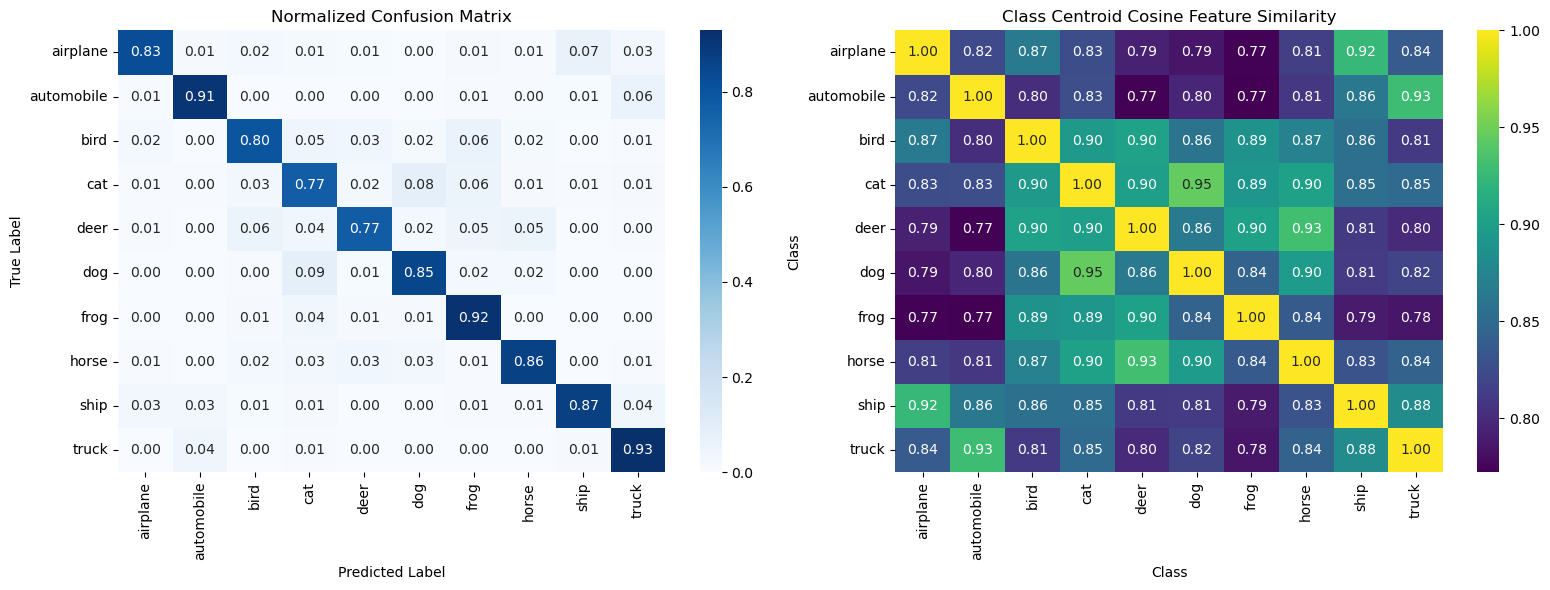

In [2]:
from task1_resnet152.src.visualize import plot_confusion_and_similarity

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
plot_confusion_and_similarity(model, val_loader, class_names, device=device, save_path='../results/figures/baseline_confusion_matrix.png')

### High-Confidence Misclassified Samples
We inspect the validation images that the model misclassified with the highest prediction confidence to analyze failure modes.

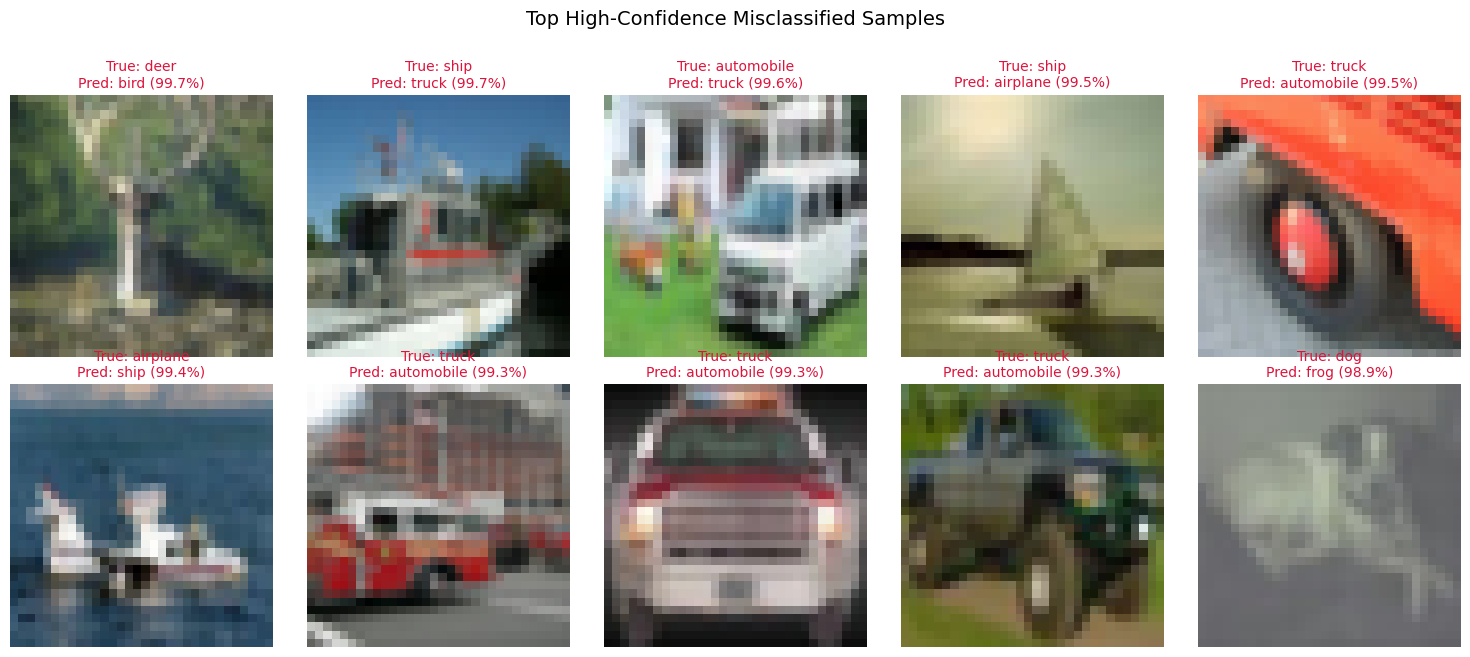

In [3]:
from task1_resnet152.src.visualize import plot_misclassified_images

plot_misclassified_images(model, val_loader, class_names, device=device, num_images=10, save_path='../results/figures/baseline_misclassified_samples.png')